# 04 - Offline Model Study (Bootstrap-Certified Analytics)

Research / analytical companion to `03_model_training.ipynb` (production training).

Trains a single CatBoost classifier with `posterior_sampling=True` (so the virtual-ensemble uncertainty pipeline in Phase 5 has what it needs) on a recent slice of the training window, caches predictions to disk, then runs a sequence of certified analytics with bootstrap CIs.

**Inputs**

- `data/model_dataset/dataset.parquet`
- `data/model_dataset/feature_list.json`

**Outputs**

- `data/model_dataset/research_predictions.parquet` (cache: k, ts, y, m_k, tau_k, phi, regime, p, split)
- `data/model_dataset/analytics/research_metrics_with_ci.json` (certified bundle)
- `data/model_dataset/analytics/research_metrics_by_regime.json`

Every analytics module lives under `src/analytics/`; the notebook is thin glue.


In [1]:
from __future__ import annotations

import sys
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd()
if not (ROOT / "docs" / "MINIMAL_PROJECT_SPEC_v2.md").exists():
    if (ROOT.parent / "docs" / "MINIMAL_PROJECT_SPEC_v2.md").exists():
        ROOT = ROOT.parent
    else:
        raise RuntimeError("Could not locate repo root")
sys.path.insert(0, str(ROOT))

from src import utils
from src.analytics.bootstrap import BootstrapResult
from src.analytics.metrics import (
    bootstrap_all_metrics,
    bootstrap_metrics_by_regime,
    by_regime_to_summary_dict,
    to_summary_dict,
)
from src.analytics.fast_train import (
    TrainSliceConfig,
    compute_predictions,
    fit_research_model,
    research_train_params,
    save_predictions_cache,
    select_recent_train_slice,
)

DATASET_DIR = ROOT / "data" / "model_dataset"
DATASET_PATH = DATASET_DIR / "dataset.parquet"
FEATURE_LIST_PATH = DATASET_DIR / "feature_list.json"
ANALYTICS_DIR = DATASET_DIR / "analytics"
PLOTS_DIR = DATASET_DIR / "plots"
ANALYTICS_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

sns.set_style("whitegrid")
warnings.filterwarnings("ignore", category=UserWarning)
print("ROOT       :", ROOT)
print("DATASET    :", DATASET_PATH)


ROOT       : C:\Users\vitil\OneDrive\Desktop\barrier_classifier
DATASET    : C:\Users\vitil\OneDrive\Desktop\barrier_classifier\data\model_dataset\dataset.parquet


## 1. Configuration

All knobs for the study live in this cell. Change defaults here, re-run from this point.


In [2]:
# Train-slice config: keep only the most recent N months of train for fast iteration.
# Set months_back=None and frac_back=None to use the full training window.
TRAIN_SLICE = TrainSliceConfig(months_back=6.0)

# Bootstrap configuration for certified metrics.
BOOTSTRAP_B = 1000
BOOTSTRAP_CI = 0.95
BOOTSTRAP_STRATIFY = True   # preserve per-class counts across resamples
BOOTSTRAP_SEED = 0

# Regime signal (spec Section 11.4)
REGIME_SIGNAL = "vol__rs__f__w240"

# Output paths
RESEARCH_CACHE_PATH = DATASET_DIR / "research_predictions.parquet"
RESEARCH_METRICS_PATH = ANALYTICS_DIR / "research_metrics_with_ci.json"
RESEARCH_REGIME_PATH = ANALYTICS_DIR / "research_metrics_by_regime.json"

print(f"Train slice : months_back={TRAIN_SLICE.months_back}  frac_back={TRAIN_SLICE.frac_back}")
print(f"Bootstrap   : B={BOOTSTRAP_B}, CI={BOOTSTRAP_CI}, stratify={BOOTSTRAP_STRATIFY}, seed={BOOTSTRAP_SEED}")
print(f"Regime sig  : {REGIME_SIGNAL}")


Train slice : months_back=6.0  frac_back=None
Bootstrap   : B=1000, CI=0.95, stratify=True, seed=0
Regime sig  : vol__rs__f__w240


## 2. Load dataset and chronological split

Same chronological split + embargo as production (`utils.chronological_split_with_embargo`).
The full training window is shown for reference; the research model below trains on only a recent slice.


In [3]:
df = pd.read_parquet(DATASET_PATH)
feature_list = utils.load_json(FEATURE_LIST_PATH)
df = df.sort_values("k").reset_index(drop=True)

missing = [c for c in feature_list if c not in df.columns]
if missing:
    raise ValueError(f"feature_list missing in dataset: {missing[:10]} (total {len(missing)})")

# Honor the feature_list.json contract — drop raw base columns the dataset
# carries alongside engineered features (open/high/low/funding_rate/oi/etc.).
# This is *not* data-quality work (that's owned by 02_feature_building); it's
# just enforcing the model-input contract before the strict NaN checkpoint.
non_feature_cols = ["k", "ts", "y", "m_k", "tau_k", "phi", "w_dist", "w_time", "weight"]
keep = set(feature_list) | set(non_feature_cols)
extras = [c for c in df.columns if c not in keep]
if extras:
    print(f"Dropping {len(extras)} columns not in feature_list (raw cols carried alongside features): "
          f"{extras[:6]}{'...' if len(extras) > 6 else ''}")
    df = df.drop(columns=extras)

train_df, val_df, test_df = utils.chronological_split_with_embargo(
    df, train_frac=utils.TRAIN_FRAC, val_frac=utils.VAL_FRAC, embargo_k=utils.EMBARGO_K,
)
# Strict pre-training validation. Data quality (NaN handling, undef flags,
# imputation) is owned by 02_feature_building; this notebook only reacts —
# checkpoint raises with a precise diagnostic if anything leaked through.
utils.checkpoint_before_training(train_df, val_df, test_df, embargo_k=utils.EMBARGO_K)

split_summary = pd.DataFrame([
    {"split": "train", "n": len(train_df), "ts_start": train_df["ts"].min(), "ts_end": train_df["ts"].max(), "base_rate": float(train_df["y"].mean())},
    {"split": "val",   "n": len(val_df),   "ts_start": val_df["ts"].min(),   "ts_end": val_df["ts"].max(),   "base_rate": float(val_df["y"].mean())},
    {"split": "test",  "n": len(test_df),  "ts_start": test_df["ts"].min(),  "ts_end": test_df["ts"].max(),  "base_rate": float(test_df["y"].mean())},
])
print(f"Total rows: {len(df):,}    Features: {len(feature_list):,}")
display(split_summary)


Dropping 46 columns not in feature_list (raw cols carried alongside features): ['open', 'high', 'low', 'close', 'volume', 'quote_volume']...
OK: Pre-training validation passed
  Train: 17,689 (70.3%)
  Val:   3,731 (14.8%)
  Test:  3,731 (14.8%)
Total rows: 25,271    Features: 1,251


,split,n,ts_start,ts_end,base_rate
0,train,17689,2025-01-15 00:01:00,2025-09-17 16:01:00,0.176324
1,val,3731,2025-09-18 12:21:00,2025-11-09 07:41:00,0.162691
2,test,3731,2025-11-10 04:01:00,2025-12-31 23:21:00,0.207183


## 3. Fit research model on recent train slice

Single seed, `posterior_sampling=True` (so virtual-ensemble uncertainty is available in Phase 5).
Iterations are capped high; early stopping does the work.

Learning curve is shown inline so it is observable mid-pipeline.


In [4]:
train_recent = select_recent_train_slice(train_df, TRAIN_SLICE)
print(f"Recent train slice : {len(train_recent):,} rows  ({train_recent['ts'].min()} -> {train_recent['ts'].max()})")
print(f"Slice base rate    : {train_recent['y'].mean():.4f}")

params = research_train_params(verbose=200)
print("\nResearch model params:")
for k, v in params.items():
    print(f"  {k}: {v}")

t0 = time.perf_counter()
model = fit_research_model(train_recent, val_df, feature_list, params=params)
fit_seconds = time.perf_counter() - t0
print(f"\nFit completed in {fit_seconds:.1f}s   best_iteration={model.get_best_iteration()}")


Recent train slice : 13,151 rows  (2025-03-19 00:41:00 -> 2025-09-17 16:01:00)
Slice base rate    : 0.1403

Research model params:
  iterations: 3000
  learning_rate: 0.01
  depth: 6
  l2_leaf_reg: 5.0
  loss_function: Logloss
  eval_metric: Logloss
  random_seed: 42
  early_stopping_rounds: 200
  border_count: 128
  thread_count: -1
  use_best_model: True
  allow_writing_files: False
  verbose: 200
  posterior_sampling: True


0:	learn: 0.6813177	test: 0.6823564	best: 0.6823564 (0)	total: 172ms	remaining: 8m 35s


200:	learn: 0.2476444	test: 0.2765252	best: 0.2765252 (200)	total: 6.57s	remaining: 1m 31s


400:	learn: 0.2339384	test: 0.2698303	best: 0.2698303 (400)	total: 13.3s	remaining: 1m 25s


600:	learn: 0.2255947	test: 0.2693553	best: 0.2692687 (573)	total: 20s	remaining: 1m 19s


Stopped by overfitting detector  (200 iterations wait)

bestTest = 0.2692686756
bestIteration = 573

Shrink model to first 574 iterations.

Fit completed in 26.1s   best_iteration=573


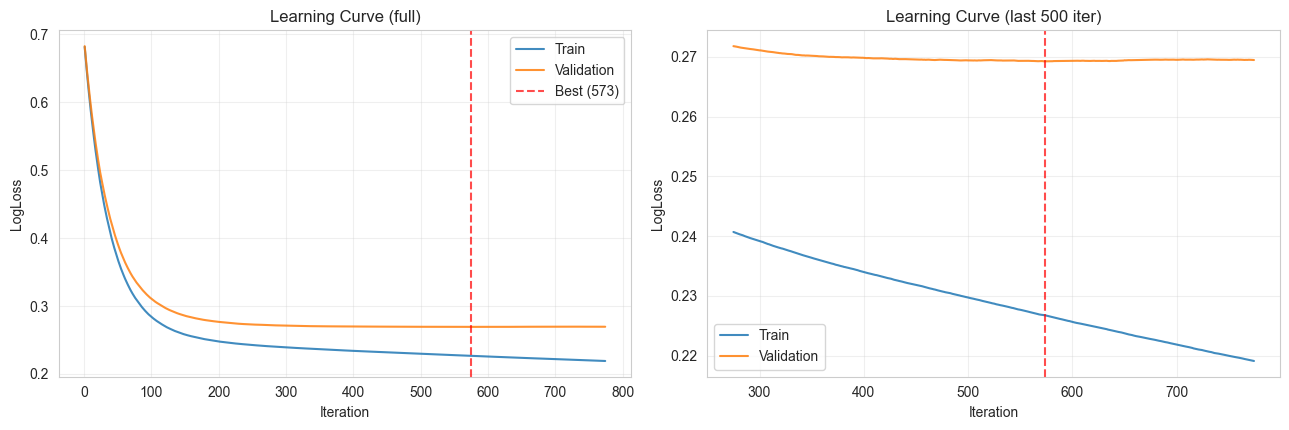

Final train LL : 0.2267
Final val   LL : 0.2693
Gap (val - tr) : +0.0425


In [5]:
# Learning curves (train + val LogLoss; full and zoomed)
evals = model.get_evals_result()
train_ll = evals.get("learn", {}).get("Logloss", [])
val_ll = evals.get("validation", evals.get("validation_0", {})).get("Logloss", [])

if train_ll and val_ll:
    iters = list(range(1, len(train_ll) + 1))
    best = int(model.get_best_iteration())
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
    axes[0].plot(iters, train_ll, label="Train", alpha=0.85)
    axes[0].plot(iters, val_ll, label="Validation", alpha=0.85)
    axes[0].axvline(best + 1, color="red", linestyle="--", alpha=0.7, label=f"Best ({best})")
    axes[0].set(xlabel="Iteration", ylabel="LogLoss", title="Learning Curve (full)")
    axes[0].legend(); axes[0].grid(alpha=0.3)
    zoom = max(0, len(train_ll) - 500)
    axes[1].plot(iters[zoom:], train_ll[zoom:], label="Train", alpha=0.85)
    axes[1].plot(iters[zoom:], val_ll[zoom:], label="Validation", alpha=0.85)
    axes[1].axvline(best + 1, color="red", linestyle="--", alpha=0.7)
    axes[1].set(xlabel="Iteration", ylabel="LogLoss", title="Learning Curve (last 500 iter)")
    axes[1].legend(); axes[1].grid(alpha=0.3)
    plt.tight_layout(); plt.show()
    print(f"Final train LL : {train_ll[best]:.4f}")
    print(f"Final val   LL : {val_ll[best]:.4f}")
    print(f"Gap (val - tr) : {val_ll[best] - train_ll[best]:+.4f}")
else:
    print("Could not extract learning curves; eval keys =", list(evals.keys()))


## 4. Compute and cache predictions

Predictions on val + test are saved to a parquet cache. **Every downstream analytics phase reads this cache** instead of retraining the model, so iteration on charts is essentially free.

Cache schema: `k, ts, y, m_k, tau_k, phi, regime, p, split`.


In [6]:
cache = compute_predictions(
    model,
    {"val": val_df, "test": test_df},
    feature_list,
    regime_signal_col=REGIME_SIGNAL,
)
save_predictions_cache(cache, RESEARCH_CACHE_PATH)
print(f"Saved cache : {RESEARCH_CACHE_PATH}  ({len(cache):,} rows)")

cache_summary = (
    cache.groupby("split")
    .agg(
        n=("p", "size"),
        base_rate=("y", "mean"),
        p_min=("p", "min"),
        p_med=("p", "median"),
        p_max=("p", "max"),
        regime_med=("regime", "median"),
    )
    .round(5)
)
display(cache_summary)


Saved cache : C:\Users\vitil\OneDrive\Desktop\barrier_classifier\data\model_dataset\research_predictions.parquet  (7,462 rows)


,n,base_rate,p_min,p_med,p_max,regime_med
split,,,,,,
test,3731,0.20718,0.01043,0.11845,0.66333,0.0004
val,3731,0.16269,0.00973,0.07906,0.65750,0.0003


## 5. Certified core metrics with bootstrap CIs

The headline metrics (ROC-AUC, PR-AUC, log-loss, Brier, ECE) are bootstrapped class-stratified iid (preserves base rate). Reading order: **point** is the metric on the full split; **CI** is the bootstrap percentile interval at `BOOTSTRAP_CI`.

Pay attention to the **width of the CI on test PR-AUC** - that is exactly the uncertainty that the legacy notebook does not report.


In [7]:
val_cache = cache[cache["split"] == "val"].reset_index(drop=True)
test_cache = cache[cache["split"] == "test"].reset_index(drop=True)

print(f"Bootstrapping core metrics: B={BOOTSTRAP_B}, CI={BOOTSTRAP_CI}, stratify={BOOTSTRAP_STRATIFY} ...")
t0 = time.perf_counter()
val_metrics = bootstrap_all_metrics(
    val_cache["y"].to_numpy(), val_cache["p"].to_numpy(),
    B=BOOTSTRAP_B, ci=BOOTSTRAP_CI, stratify=BOOTSTRAP_STRATIFY, seed=BOOTSTRAP_SEED,
)
test_metrics = bootstrap_all_metrics(
    test_cache["y"].to_numpy(), test_cache["p"].to_numpy(),
    B=BOOTSTRAP_B, ci=BOOTSTRAP_CI, stratify=BOOTSTRAP_STRATIFY, seed=BOOTSTRAP_SEED,
)
print(f"Bootstrap completed in {time.perf_counter() - t0:.1f}s")

def _ci(r: BootstrapResult) -> str:
    return f"[{r.ci_low:.4f}, {r.ci_high:.4f}]"
def _width(r: BootstrapResult) -> float:
    return float(r.ci_high - r.ci_low)

rows = []
for name in val_metrics:
    v, t = val_metrics[name], test_metrics[name]
    rows.append({
        "metric": name,
        "val (point)": v.point,
        "val 95% CI": _ci(v),
        "val width": _width(v),
        "test (point)": t.point,
        "test 95% CI": _ci(t),
        "test width": _width(t),
    })
metrics_table = pd.DataFrame(rows)
display(metrics_table.style.format({"val (point)": "{:.4f}", "val width": "{:.4f}", "test (point)": "{:.4f}", "test width": "{:.4f}"}))

bundle = {
    "config": {"B": BOOTSTRAP_B, "ci": BOOTSTRAP_CI, "stratify": BOOTSTRAP_STRATIFY, "seed": BOOTSTRAP_SEED, "regime_signal": REGIME_SIGNAL},
    "val": {"n_samples": int(len(val_cache)), "base_rate": float(val_cache["y"].mean()), **to_summary_dict(val_metrics)},
    "test": {"n_samples": int(len(test_cache)), "base_rate": float(test_cache["y"].mean()), **to_summary_dict(test_metrics)},
    "best_iteration": int(model.get_best_iteration()),
    "fit_seconds": float(fit_seconds),
    "train_slice": {
        "months_back": TRAIN_SLICE.months_back,
        "frac_back": TRAIN_SLICE.frac_back,
        "n_train": int(len(train_recent)),
        "ts_start": str(train_recent["ts"].min()),
        "ts_end": str(train_recent["ts"].max()),
    },
}
utils.save_json(RESEARCH_METRICS_PATH, bundle)
print(f"\nSaved certified metrics : {RESEARCH_METRICS_PATH}")


Bootstrapping core metrics: B=1000, CI=0.95, stratify=True ...


Bootstrap completed in 5.9s


,metric,val (point),val 95% CI,val width,test (point),test 95% CI,test width
0,roc_auc,0.7744,"[0.7548, 0.7933]",0.0385,0.7513,"[0.7313, 0.7693]",0.0380
1,pr_auc,0.4105,"[0.3774, 0.4497]",0.0723,0.4255,"[0.3957, 0.4579]",0.0622
2,log_loss,0.3884,"[0.3783, 0.3986]",0.0203,0.4560,"[0.4455, 0.4667]",0.0212
3,brier_score,0.1204,"[0.1178, 0.1231]",0.0053,0.1470,"[0.1438, 0.1501]",0.0063
4,ece_10bin,0.0509,"[0.0480, 0.0542]",0.0062,0.0577,"[0.0544, 0.0621]",0.0077



Saved certified metrics : C:\Users\vitil\OneDrive\Desktop\barrier_classifier\data\model_dataset\analytics\research_metrics_with_ci.json


## 6. Per-regime certified metrics

Tercile breakdown by `vol__rs__f__w240`. The legacy analytics flagged that high-vol calibration is materially worse than low-vol; the bootstrap CIs let us judge whether that gap is real or sampling noise.

Two views:

1. Tabular: per (split, regime), point + CI for every metric.
2. Chart: ECE-by-regime barplot with CI error bars (val vs test side-by-side).


In [8]:
print("Bootstrapping metrics per volatility regime ...")
t0 = time.perf_counter()
val_by_regime = bootstrap_metrics_by_regime(
    val_cache["y"].to_numpy(), val_cache["p"].to_numpy(), val_cache["regime"].to_numpy(),
    B=BOOTSTRAP_B, ci=BOOTSTRAP_CI, stratify=BOOTSTRAP_STRATIFY, seed=BOOTSTRAP_SEED,
)
test_by_regime = bootstrap_metrics_by_regime(
    test_cache["y"].to_numpy(), test_cache["p"].to_numpy(), test_cache["regime"].to_numpy(),
    B=BOOTSTRAP_B, ci=BOOTSTRAP_CI, stratify=BOOTSTRAP_STRATIFY, seed=BOOTSTRAP_SEED,
)
print(f"Per-regime bootstrap completed in {time.perf_counter() - t0:.1f}s")

def _regime_table(by_regime, split_name, cache_df):
    rows = []
    terciles = pd.qcut(cache_df["regime"], 3, labels=["low", "med", "high"])
    for label in ["low", "med", "high"]:
        if label not in by_regime:
            continue
        m = by_regime[label]
        mask = np.asarray(terciles == label)
        row = {
            "split": split_name,
            "regime": label,
            "n": int(mask.sum()),
            "base_rate": float(cache_df.loc[mask, "y"].mean()),
        }
        for name in ["roc_auc", "pr_auc", "brier_score", "ece_10bin"]:
            r = m.get(name)
            if r is None:
                continue
            row[f"{name}"] = r.point
            row[f"{name}_ci"] = f"[{r.ci_low:.4f}, {r.ci_high:.4f}]"
        rows.append(row)
    return pd.DataFrame(rows)

regime_table = pd.concat([
    _regime_table(val_by_regime, "val", val_cache),
    _regime_table(test_by_regime, "test", test_cache),
], ignore_index=True)
display(regime_table.style.format({"base_rate": "{:.4f}", "roc_auc": "{:.4f}", "pr_auc": "{:.4f}", "brier_score": "{:.4f}", "ece_10bin": "{:.4f}"}))


Bootstrapping metrics per volatility regime ...


Per-regime bootstrap completed in 11.0s


,split,regime,n,base_rate,roc_auc,roc_auc_ci,pr_auc,pr_auc_ci,brier_score,brier_score_ci,ece_10bin,ece_10bin_ci
0,val,low,1244,0.0490,0.6836,"[0.6185, 0.7531]",0.1202,"[0.0841, 0.1947]",0.0459,"[0.0452, 0.0466]",0.0184,"[0.0172, 0.0196]"
1,val,med,1243,0.1279,0.6805,"[0.6384, 0.7224]",0.2355,"[0.1999, 0.2958]",0.1082,"[0.1060, 0.1102]",0.0360,"[0.0336, 0.0434]"
2,val,high,1244,0.3111,0.6697,"[0.6376, 0.7028]",0.4879,"[0.4495, 0.5337]",0.2072,"[0.2014, 0.2128]",0.0993,"[0.0938, 0.1063]"
3,test,low,1244,0.0699,0.6937,"[0.6369, 0.7459]",0.1341,"[0.1088, 0.1867]",0.0639,"[0.0627, 0.0651]",0.0238,"[0.0223, 0.0317]"
4,test,med,1243,0.1979,0.6666,"[0.6311, 0.7012]",0.3335,"[0.2907, 0.3871]",0.1546,"[0.1511, 0.1582]",0.0637,"[0.0607, 0.0712]"
5,test,high,1244,0.3537,0.6464,"[0.6144, 0.6798]",0.4902,"[0.4553, 0.5334]",0.2225,"[0.2166, 0.2283]",0.0873,"[0.0823, 0.0975]"


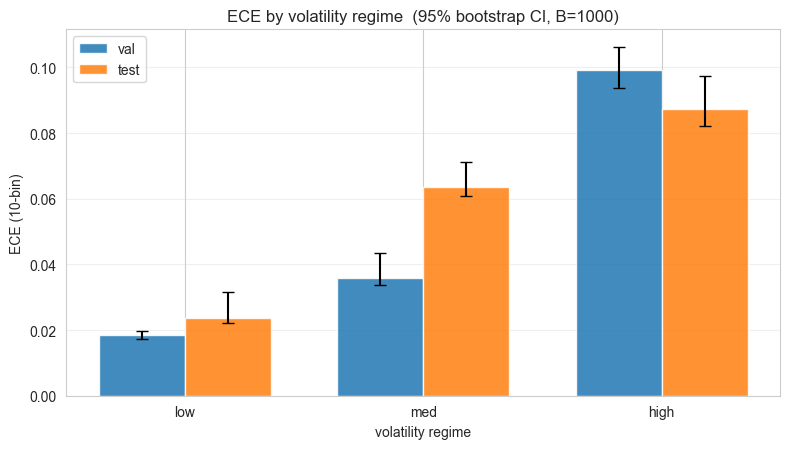

Saved per-regime metrics : C:\Users\vitil\OneDrive\Desktop\barrier_classifier\data\model_dataset\analytics\research_metrics_by_regime.json
Saved chart              : C:\Users\vitil\OneDrive\Desktop\barrier_classifier\data\model_dataset\plots\research_ece_by_regime.png


In [9]:
# ECE-by-regime barplot with bootstrap CI error bars (val vs test)
regimes = ["low", "med", "high"]
x = np.arange(len(regimes))
width = 0.36
fig, ax = plt.subplots(figsize=(8, 4.6))
for i, (split, by_regime) in enumerate([("val", val_by_regime), ("test", test_by_regime)]):
    points, lo_err, hi_err = [], [], []
    for r in regimes:
        if r not in by_regime or "ece_10bin" not in by_regime[r]:
            points.append(np.nan); lo_err.append(0.0); hi_err.append(0.0); continue
        m = by_regime[r]["ece_10bin"]
        points.append(m.point)
        lo_err.append(max(0.0, m.point - m.ci_low))
        hi_err.append(max(0.0, m.ci_high - m.point))
    ax.bar(x + (i - 0.5) * width, points, width=width, yerr=[lo_err, hi_err], capsize=4, label=split, alpha=0.85)
ax.set(xticks=x, xticklabels=regimes, ylabel="ECE (10-bin)", xlabel="volatility regime",
       title=f"ECE by volatility regime  (95% bootstrap CI, B={BOOTSTRAP_B})")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
fig.savefig(PLOTS_DIR / "research_ece_by_regime.png", dpi=150)
plt.show()

regime_bundle = {
    "val": by_regime_to_summary_dict(val_by_regime),
    "test": by_regime_to_summary_dict(test_by_regime),
}
utils.save_json(RESEARCH_REGIME_PATH, regime_bundle)
print(f"Saved per-regime metrics : {RESEARCH_REGIME_PATH}")
print(f"Saved chart              : {PLOTS_DIR / 'research_ece_by_regime.png'}")


## 7. Curves with bootstrap quantile bands

Three curves, each with the 95% per-grid-point bootstrap percentile band:

- **ROC** — TPR vs FPR (linear interpolation onto a 201-point FPR grid; upper-envelope at duplicate FPRs)
- **PR** — Precision vs recall (Pascal-VOC max-envelope onto a 201-point recall grid)
- **Calibration** — empirical y vs mean predicted p (10 equal-width bins, per-bin CI on empirical y)

Tight CIs in the operating range mean the model's behavior there is well-determined; wide CIs (especially in PR's high-precision low-recall corner) flag where the test-set point estimate is misleading.


In [10]:
from src.analytics.curves import (
    bootstrap_calibration_curve,
    bootstrap_pr_curve,
    bootstrap_roc_curve,
    plot_calibration_with_ci,
    plot_pr_with_band,
    plot_roc_with_band,
)

print(f"Bootstrapping curves: B={BOOTSTRAP_B}, CI={BOOTSTRAP_CI}, stratify={BOOTSTRAP_STRATIFY} ...")
t0 = time.perf_counter()
val_roc = bootstrap_roc_curve(val_cache["y"].to_numpy(), val_cache["p"].to_numpy(),
    B=BOOTSTRAP_B, ci=BOOTSTRAP_CI, stratify=BOOTSTRAP_STRATIFY, seed=BOOTSTRAP_SEED)
test_roc = bootstrap_roc_curve(test_cache["y"].to_numpy(), test_cache["p"].to_numpy(),
    B=BOOTSTRAP_B, ci=BOOTSTRAP_CI, stratify=BOOTSTRAP_STRATIFY, seed=BOOTSTRAP_SEED)
val_pr = bootstrap_pr_curve(val_cache["y"].to_numpy(), val_cache["p"].to_numpy(),
    B=BOOTSTRAP_B, ci=BOOTSTRAP_CI, stratify=BOOTSTRAP_STRATIFY, seed=BOOTSTRAP_SEED)
test_pr = bootstrap_pr_curve(test_cache["y"].to_numpy(), test_cache["p"].to_numpy(),
    B=BOOTSTRAP_B, ci=BOOTSTRAP_CI, stratify=BOOTSTRAP_STRATIFY, seed=BOOTSTRAP_SEED)
val_cal = bootstrap_calibration_curve(val_cache["y"].to_numpy(), val_cache["p"].to_numpy(),
    n_bins=10, B=BOOTSTRAP_B, ci=BOOTSTRAP_CI, stratify=BOOTSTRAP_STRATIFY, seed=BOOTSTRAP_SEED)
test_cal = bootstrap_calibration_curve(test_cache["y"].to_numpy(), test_cache["p"].to_numpy(),
    n_bins=10, B=BOOTSTRAP_B, ci=BOOTSTRAP_CI, stratify=BOOTSTRAP_STRATIFY, seed=BOOTSTRAP_SEED)
print(f"Curve bootstrap completed in {time.perf_counter() - t0:.1f}s")


Bootstrapping curves: B=1000, CI=0.95, stratify=True ...


C:\Users\vitil\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\nanfunctions.py:1563: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,


Curve bootstrap completed in 6.8s


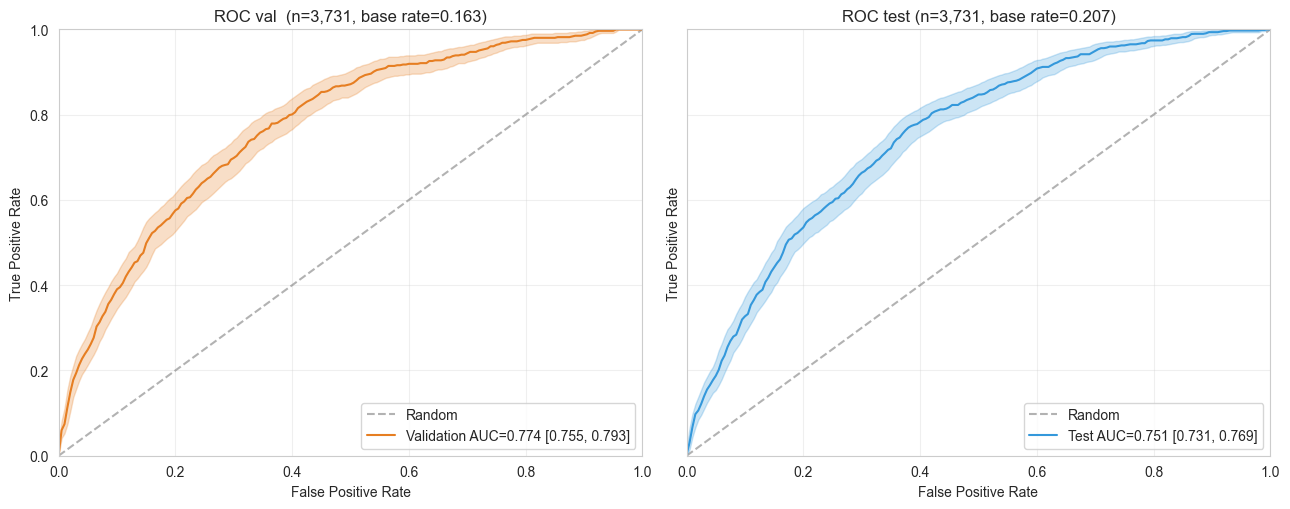

Saved: C:\Users\vitil\OneDrive\Desktop\barrier_classifier\data\model_dataset\plots\research_roc_with_band.png


In [11]:
# Side-by-side ROC: val vs test, both with 95% bootstrap bands
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2), sharey=True)
plot_roc_with_band(val_roc,  ax=axes[0], color="#e67e22", label="Validation")
plot_roc_with_band(test_roc, ax=axes[1], color="#3498db", label="Test", plot_diagonal=True)
axes[0].set_title(f"ROC val  (n={len(val_cache):,}, base rate={val_cache['y'].mean():.3f})")
axes[1].set_title(f"ROC test (n={len(test_cache):,}, base rate={test_cache['y'].mean():.3f})")
plt.tight_layout()
fig.savefig(PLOTS_DIR / "research_roc_with_band.png", dpi=150)
plt.show()
print(f"Saved: {PLOTS_DIR / 'research_roc_with_band.png'}")


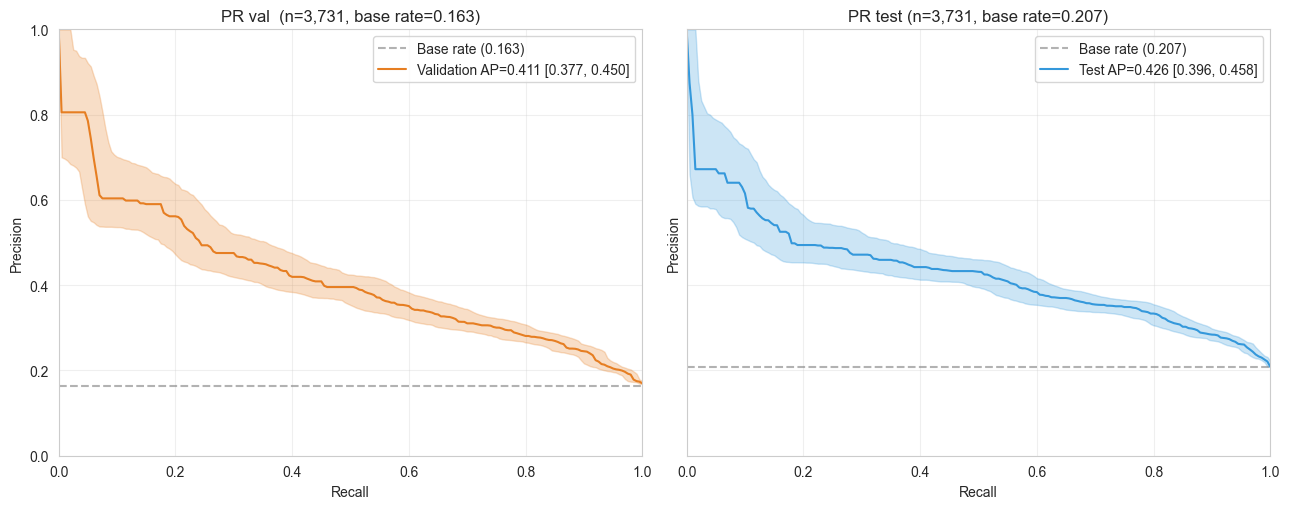

Saved: C:\Users\vitil\OneDrive\Desktop\barrier_classifier\data\model_dataset\plots\research_pr_with_band.png


In [12]:
# Side-by-side PR: val vs test, with base-rate reference and 95% bands
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2), sharey=True)
plot_pr_with_band(val_pr,  ax=axes[0], base_rate=float(val_cache["y"].mean()),
                  color="#e67e22", label="Validation")
plot_pr_with_band(test_pr, ax=axes[1], base_rate=float(test_cache["y"].mean()),
                  color="#3498db", label="Test")
axes[0].set_title(f"PR val  (n={len(val_cache):,}, base rate={val_cache['y'].mean():.3f})")
axes[1].set_title(f"PR test (n={len(test_cache):,}, base rate={test_cache['y'].mean():.3f})")
plt.tight_layout()
fig.savefig(PLOTS_DIR / "research_pr_with_band.png", dpi=150)
plt.show()
print(f"Saved: {PLOTS_DIR / 'research_pr_with_band.png'}")


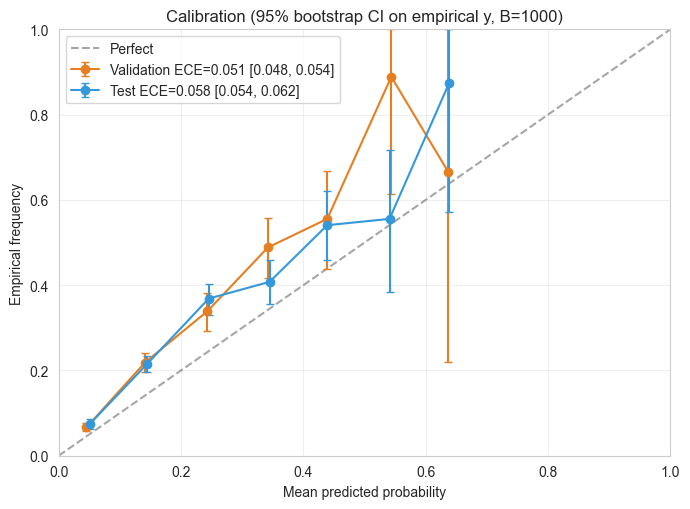

Saved: C:\Users\vitil\OneDrive\Desktop\barrier_classifier\data\model_dataset\plots\research_calibration_with_ci.png


In [13]:
# Calibration: val + test on a single axis with bootstrap CIs
fig, ax = plt.subplots(figsize=(7, 5.2))
plot_calibration_with_ci(val_cal,  ax=ax, color="#e67e22", label="Validation", plot_perfect=True)
plot_calibration_with_ci(test_cal, ax=ax, color="#3498db", label="Test",       plot_perfect=False)
ax.set_title(f"Calibration (95% bootstrap CI on empirical y, B={BOOTSTRAP_B})")
plt.tight_layout()
fig.savefig(PLOTS_DIR / "research_calibration_with_ci.png", dpi=150)
plt.show()
print(f"Saved: {PLOTS_DIR / 'research_calibration_with_ci.png'}")


In [14]:
# Save curve summaries (JSON, excludes raw bootstrap samples)
curves_bundle = {
    "val":  {
        "roc": val_roc.to_summary_dict(),
        "pr":  val_pr.to_summary_dict(),
        "calibration": val_cal.to_summary_dict(),
    },
    "test": {
        "roc": test_roc.to_summary_dict(),
        "pr":  test_pr.to_summary_dict(),
        "calibration": test_cal.to_summary_dict(),
    },
}
utils.save_json(ANALYTICS_DIR / "research_curves_summary.json", curves_bundle)
display(pd.DataFrame([
    {"split": "val",  "ROC-AUC": val_roc.auc_point,  "ROC-AUC CI": f"[{val_roc.auc_ci_low:.3f}, {val_roc.auc_ci_high:.3f}]",
     "PR-AP":  val_pr.auc_point,  "PR-AP CI":  f"[{val_pr.auc_ci_low:.3f}, {val_pr.auc_ci_high:.3f}]",
     "ECE":    val_cal.auc_point, "ECE CI":    f"[{val_cal.auc_ci_low:.3f}, {val_cal.auc_ci_high:.3f}]"},
    {"split": "test", "ROC-AUC": test_roc.auc_point, "ROC-AUC CI": f"[{test_roc.auc_ci_low:.3f}, {test_roc.auc_ci_high:.3f}]",
     "PR-AP":  test_pr.auc_point, "PR-AP CI":  f"[{test_pr.auc_ci_low:.3f}, {test_pr.auc_ci_high:.3f}]",
     "ECE":    test_cal.auc_point,"ECE CI":    f"[{test_cal.auc_ci_low:.3f}, {test_cal.auc_ci_high:.3f}]"},
]).style.format({"ROC-AUC": "{:.4f}", "PR-AP": "{:.4f}", "ECE": "{:.4f}"}))
print(f"Saved curve summaries: {ANALYTICS_DIR / 'research_curves_summary.json'}")


,split,ROC-AUC,ROC-AUC CI,PR-AP,PR-AP CI,ECE,ECE CI
0,val,0.7744,"[0.755, 0.793]",0.4105,"[0.377, 0.450]",0.0509,"[0.048, 0.054]"
1,test,0.7513,"[0.731, 0.769]",0.4255,"[0.396, 0.458]",0.0577,"[0.054, 0.062]"


Saved curve summaries: C:\Users\vitil\OneDrive\Desktop\barrier_classifier\data\model_dataset\analytics\research_curves_summary.json


## 8. Time-degradation diagnostics

Operating on the cached predictions (no retraining), four diagnostics:

1. **Rolling metrics with CI bands** — per-window ROC-AUC, PR-AUC, Brier, ECE. Reveals stability over time and where the model is reliably better/worse than its split-aggregate.
2. **Brier-Murphy decomposition over time** — splits Brier into Reliability + Resolution + Uncertainty + within-bin variance. Identity holds on the *binned* Brier: `BS_binned = REL - RES + UNC`. When Reliability rises but Resolution holds, the right action is recalibration; when Resolution falls, you need a refit.
3. **PSI / KS rolling** — measures probability-distribution drift of test windows vs the full validation distribution. PSI > 0.1 = moderate drift; > 0.2 = significant.
4. **Conditional precision heatmap** — precision at a fixed operating threshold, conditioned on (vol regime × hour-of-day). Wilson 95% CIs handle small per-cell counts robustly.


In [15]:
from src.analytics.degradation import (
    conditional_precision,
    plot_brier_decomposition_over_time,
    plot_conditional_precision_heatmap,
    plot_psi_ks_over_time,
    plot_rolling_metric_with_band,
    psi_ks_rolling,
    rolling_brier_decomposition,
    rolling_metrics_with_ci,
)

ROLL_WINDOW = "3D"
ROLL_STEP = "1D"
ROLL_B = 300
ROLL_MIN_N = 150
ROLL_MIN_POS = 15

print(f"Rolling window={ROLL_WINDOW}, step={ROLL_STEP}, B={ROLL_B}")

t0 = time.perf_counter()
rolling_test = rolling_metrics_with_ci(
    cache, split="test", window=ROLL_WINDOW, step=ROLL_STEP,
    B=ROLL_B, ci=BOOTSTRAP_CI, stratify=BOOTSTRAP_STRATIFY, seed=BOOTSTRAP_SEED,
    min_n=ROLL_MIN_N, min_pos=ROLL_MIN_POS,
)
print(f"Rolling metrics: {len(rolling_test)} windows, {time.perf_counter() - t0:.1f}s")
display(rolling_test[["window_end", "n_samples", "n_pos", "base_rate",
                      "roc_auc_point", "pr_auc_point", "brier_score_point", "ece_10bin_point"]].head())


Rolling window=3D, step=1D, B=300


Rolling metrics: 47 windows, 14.3s


,window_end,n_samples,n_pos,base_rate,roc_auc_point,pr_auc_point,brier_score_point,ece_10bin_point
0,2025-11-13 04:01:00,216,37,0.171296,0.609392,0.251614,0.139088,0.037961
1,2025-11-14 04:01:00,216,41,0.189815,0.670941,0.348157,0.144711,0.041979
2,2025-11-15 04:01:00,216,61,0.282407,0.658805,0.452671,0.190942,0.061686
3,2025-11-16 04:01:00,216,59,0.273148,0.690489,0.469638,0.181879,0.051231
4,2025-11-17 04:01:00,216,59,0.273148,0.699449,0.457376,0.182195,0.057702


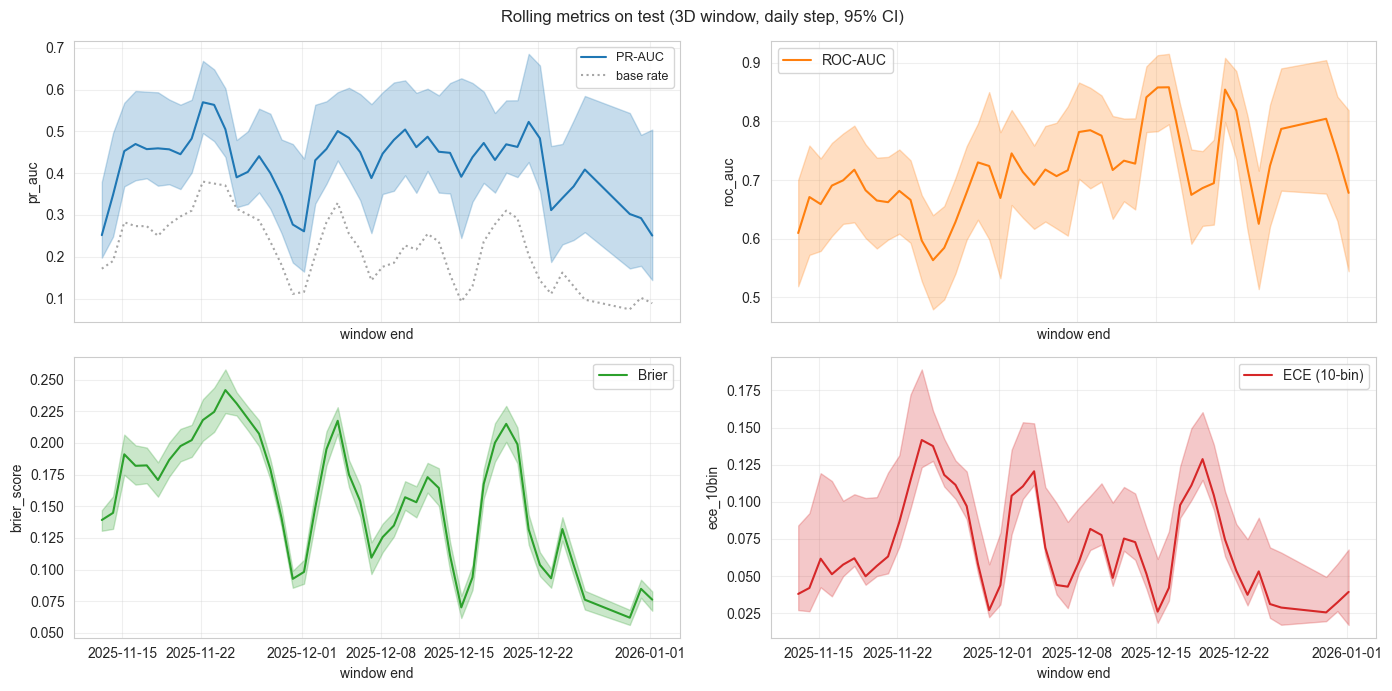

Saved: C:\Users\vitil\OneDrive\Desktop\barrier_classifier\data\model_dataset\plots\research_rolling_metrics.png


In [16]:
# Rolling metrics 4-panel: PR-AUC / ROC-AUC / Brier / ECE with bootstrap bands
fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharex=True)
plot_rolling_metric_with_band(rolling_test, "pr_auc",      ax=axes[0, 0], color="C0", label="PR-AUC")
plot_rolling_metric_with_band(rolling_test, "roc_auc",     ax=axes[0, 1], color="C1", label="ROC-AUC")
plot_rolling_metric_with_band(rolling_test, "brier_score", ax=axes[1, 0], color="C2", label="Brier")
plot_rolling_metric_with_band(rolling_test, "ece_10bin",   ax=axes[1, 1], color="C3", label="ECE (10-bin)")
# Overlay base rate on PR-AUC panel for reference
axes[0, 0].plot(rolling_test["window_end"], rolling_test["base_rate"],
                linestyle=":", color="gray", alpha=0.7, label="base rate")
axes[0, 0].legend(loc="upper right", fontsize=9)
fig.suptitle(f"Rolling metrics on test ({ROLL_WINDOW} window, daily step, 95% CI)")
plt.tight_layout()
fig.savefig(PLOTS_DIR / "research_rolling_metrics.png", dpi=150)
plt.show()
print(f"Saved: {PLOTS_DIR / 'research_rolling_metrics.png'}")


Brier decomposition: 47 windows, 7.0s


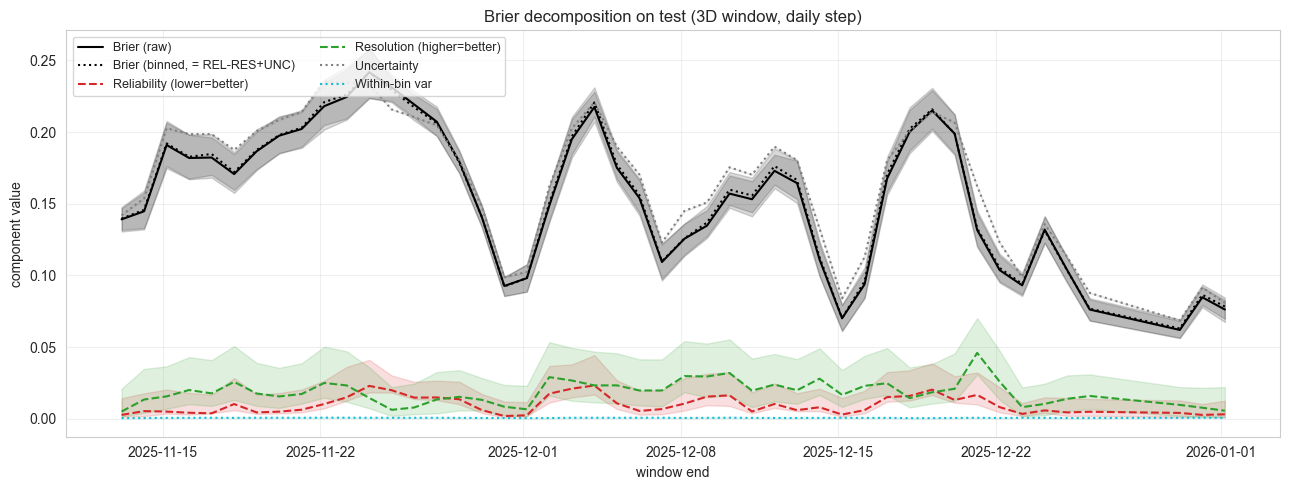

Saved: C:\Users\vitil\OneDrive\Desktop\barrier_classifier\data\model_dataset\plots\research_brier_decomposition.png


In [17]:
# Rolling Brier-Murphy decomposition (REL, RES, UNC, WBV components)
t0 = time.perf_counter()
rolling_brier = rolling_brier_decomposition(
    cache, split="test", window=ROLL_WINDOW, step=ROLL_STEP, n_bins=10,
    B=ROLL_B, ci=BOOTSTRAP_CI, stratify=BOOTSTRAP_STRATIFY, seed=BOOTSTRAP_SEED,
    min_n=ROLL_MIN_N, min_pos=ROLL_MIN_POS,
)
print(f"Brier decomposition: {len(rolling_brier)} windows, {time.perf_counter() - t0:.1f}s")

fig, ax = plt.subplots(figsize=(13, 5))
plot_brier_decomposition_over_time(rolling_brier, ax=ax)
ax.set_title(f"Brier decomposition on test ({ROLL_WINDOW} window, daily step)")
plt.tight_layout()
fig.savefig(PLOTS_DIR / "research_brier_decomposition.png", dpi=150)
plt.show()
print(f"Saved: {PLOTS_DIR / 'research_brier_decomposition.png'}")


Drift windows: 50


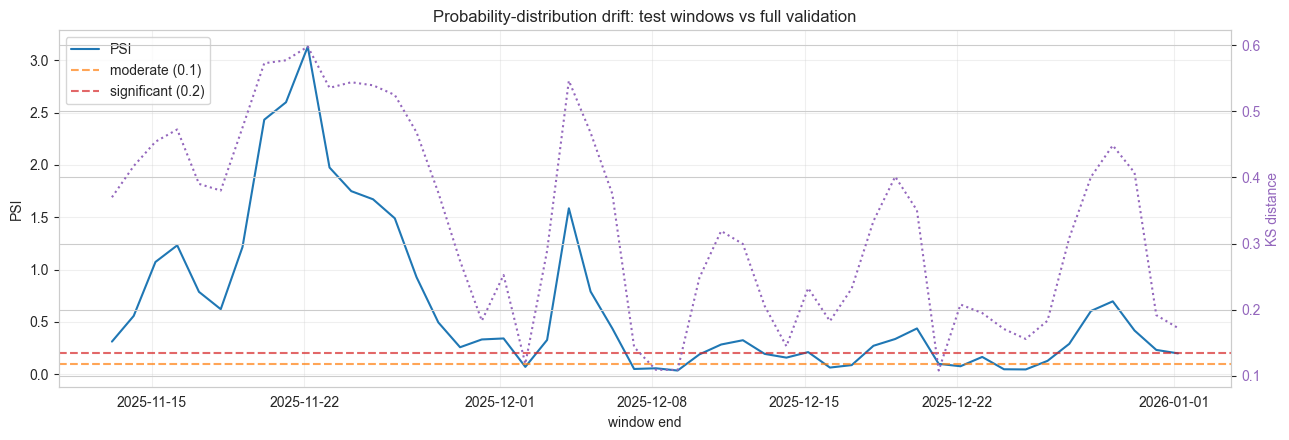

Saved: C:\Users\vitil\OneDrive\Desktop\barrier_classifier\data\model_dataset\plots\research_psi_ks_over_time.png

PSI median 0.329, max 3.132  (>0.1 = moderate drift, >0.2 = significant)
KS  median 0.326,  max 0.598


In [18]:
# Rolling PSI / KS — test windows vs full validation distribution
drift = psi_ks_rolling(
    cache, reference_split="val", target_split="test",
    window=ROLL_WINDOW, step=ROLL_STEP, n_bins=10, min_n=ROLL_MIN_N,
)
print(f"Drift windows: {len(drift)}")

fig, ax = plt.subplots(figsize=(13, 4.5))
plot_psi_ks_over_time(drift, ax=ax)
ax.set_title("Probability-distribution drift: test windows vs full validation")
plt.tight_layout()
fig.savefig(PLOTS_DIR / "research_psi_ks_over_time.png", dpi=150)
plt.show()
print(f"Saved: {PLOTS_DIR / 'research_psi_ks_over_time.png'}")
print()
print(f"PSI median {drift['psi'].median():.3f}, max {drift['psi'].max():.3f}  "
      f"(>0.1 = moderate drift, >0.2 = significant)")
print(f"KS  median {drift['ks'].median():.3f},  max {drift['ks'].max():.3f}")


C:\Users\vitil\OneDrive\Desktop\barrier_classifier\src\analytics\degradation.py:694: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot = pivot.applymap(lambda v: "" if np.isnan(v) else f"{v:.2f}")


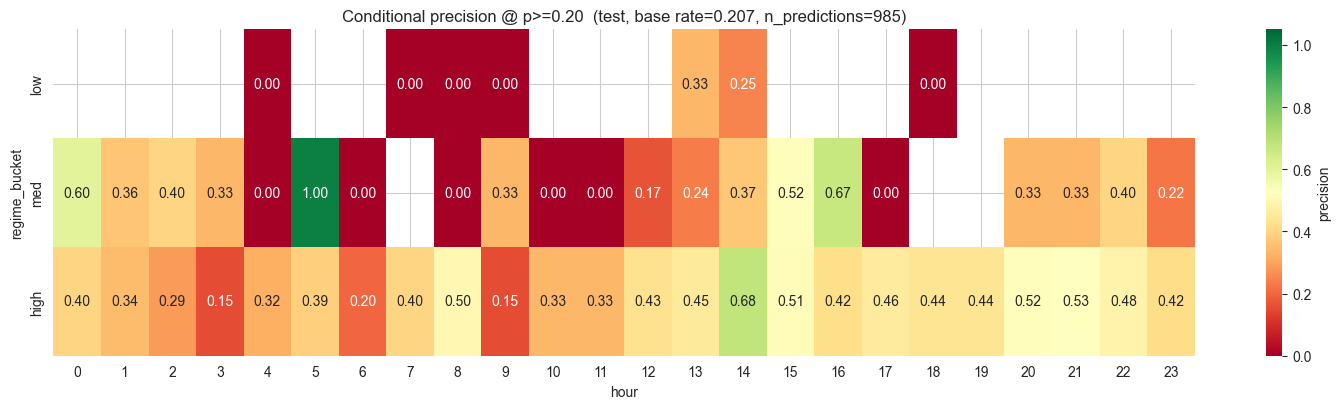

Saved: C:\Users\vitil\OneDrive\Desktop\barrier_classifier\data\model_dataset\plots\research_conditional_precision.png


hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
regime_bucket,,,,,,,,,,,,,,,,,,,,,
low,0,0,0,0,1,0,0,1,1,1,...,4,0,0,0,1,0,0,0,0,0
med,10,11,10,6,3,2,1,0,1,3,...,30,27,3,2,0,0,3,3,5,9
high,25,32,35,26,22,18,15,15,10,13,...,31,82,93,83,73,62,52,40,33,24


In [19]:
# Conditional precision heatmap (vol regime x hour-of-day) at the operating threshold
OPERATING_THRESHOLD = 0.20  # near the knee of the threshold curve from Section 6

cond = conditional_precision(
    cache, threshold=OPERATING_THRESHOLD, split="test",
    by=("regime_bucket", "hour"), n_regime_buckets=3,
)

fig, ax = plt.subplots(figsize=(15, 4.2))
plot_conditional_precision_heatmap(
    cond, index_col="regime_bucket", column_col="hour",
    value_col="precision", annotate="value", ax=ax,
    vmin=0.0, vmax=cond["precision"].max() * 1.05 if len(cond) else 1.0,
)
ax.set_title(
    f"Conditional precision @ p>={OPERATING_THRESHOLD:.2f}  "
    f"(test, base rate={test_cache['y'].mean():.3f}, n_predictions={int(cond['n_predictions'].sum())})"
)
plt.tight_layout()
fig.savefig(PLOTS_DIR / "research_conditional_precision.png", dpi=150)
plt.show()
print(f"Saved: {PLOTS_DIR / 'research_conditional_precision.png'}")

# Also show the supporting table of cell counts and CIs
display(cond.pivot(index="regime_bucket", columns="hour", values="n_predictions").fillna(0).astype(int))


In [20]:
# Save degradation summaries
import json
degradation_bundle = {
    "config": {"window": ROLL_WINDOW, "step": ROLL_STEP, "B": ROLL_B,
               "min_n": ROLL_MIN_N, "min_pos": ROLL_MIN_POS,
               "operating_threshold": OPERATING_THRESHOLD},
    "n_rolling_windows": int(len(rolling_test)),
    "psi_summary": {
        "median": float(drift["psi"].median()) if len(drift) else None,
        "max": float(drift["psi"].max()) if len(drift) else None,
        "n_above_0.1": int((drift["psi"] > 0.1).sum()) if len(drift) else 0,
        "n_above_0.2": int((drift["psi"] > 0.2).sum()) if len(drift) else 0,
    },
    "ks_summary": {
        "median": float(drift["ks"].median()) if len(drift) else None,
        "max": float(drift["ks"].max()) if len(drift) else None,
    },
    "conditional_precision": {
        "n_cells_populated": int(len(cond)),
        "median_precision": float(cond["precision"].median()) if len(cond) else None,
        "min_precision": float(cond["precision"].min()) if len(cond) else None,
        "max_precision": float(cond["precision"].max()) if len(cond) else None,
    },
}
utils.save_json(ANALYTICS_DIR / "research_degradation_summary.json", degradation_bundle)
print(f"Saved degradation summary: {ANALYTICS_DIR / 'research_degradation_summary.json'}")
print(json.dumps(degradation_bundle, indent=2, default=str))


Saved degradation summary: C:\Users\vitil\OneDrive\Desktop\barrier_classifier\data\model_dataset\analytics\research_degradation_summary.json
{
  "config": {
    "window": "3D",
    "step": "1D",
    "B": 300,
    "min_n": 150,
    "min_pos": 15,
    "operating_threshold": 0.2
  },
  "n_rolling_windows": 47,
  "psi_summary": {
    "median": 0.329154041194635,
    "max": 3.1322495348274413,
    "n_above_0.1": 40,
    "n_above_0.2": 34
  },
  "ks_summary": {
    "median": 0.32645217248875785,
    "max": 0.5976664482762044
  },
  "conditional_precision": {
    "n_cells_populated": 52,
    "median_precision": 0.3333333333333333,
    "min_precision": 0.0,
    "max_precision": 1.0
  }
}


## 9. Tail / edge analysis

The operating-point view: which thresholds are worth using, what's the realized edge per trade, and where does Kelly turn negative? Five charts:

1. **Threshold sweep with bootstrap CIs** — precision, recall, trade-rate, lift over base rate at every threshold.
2. **Net EV per trade vs trades-per-day** (the canonical operating chart) — log-x trades-per-day; net EV in log-return units; bootstrap band per threshold. Overlaid break-even line at 0.
3. **Kelly fraction by probability decile** — empirical hit rate per decile (Wilson 95% CI) plus the implied Kelly fraction under the configured outcome model.
4. **Lift / gain curve** — cumulative precision when taking the top-k by p, vs random baseline.
5. **Partial AUC** in the operating bands (FPR <= 5%, recall <= 10%) with bootstrap CIs.

**Outcome model** (configurable in the cell below): default assumes `gain_per_hit = phi`, `loss_per_miss = phi` (symmetric — conservative for entry-only), `cost_per_trade = 5 bps`. For accurate EV with a real exit policy, add an `r_realized` column to the dataset in 02_feature_building and pass `use_realized_return=True`.


In [21]:
from src.analytics.edge import (
    OutcomeModel,
    bootstrap_partial_pr_auc,
    bootstrap_partial_roc_auc,
    bootstrap_threshold_sweep,
    kelly_by_bin,
    lift_curve,
    plot_kelly_by_bin,
    plot_lift_curve,
    plot_net_ev_vs_trades_per_day,
    plot_threshold_sweep_with_bands,
)

OUTCOME_MODEL = OutcomeModel(
    gain_per_hit=float(test_cache["phi"].iloc[0]),
    loss_per_miss=float(test_cache["phi"].iloc[0]),  # symmetric default; override per strategy
    cost_per_trade=0.0005,
    use_realized_return=False,
)
print(f"Outcome model: gain={OUTCOME_MODEL.gain_per_hit:.5f}, "
      f"loss={OUTCOME_MODEL.loss_per_miss:.5f}, "
      f"cost={OUTCOME_MODEL.cost_per_trade:.5f}, "
      f"use_realized={OUTCOME_MODEL.use_realized_return}")

EDGE_THRESHOLDS = np.linspace(0.05, float(test_cache["p"].max()), 80)

t0 = time.perf_counter()
sweep = bootstrap_threshold_sweep(
    cache, split="test", thresholds=EDGE_THRESHOLDS,
    outcome_model=OUTCOME_MODEL,
    B=BOOTSTRAP_B, ci=BOOTSTRAP_CI, stratify=BOOTSTRAP_STRATIFY, seed=BOOTSTRAP_SEED,
)
print(f"Threshold sweep: {len(sweep)} thresholds, {time.perf_counter() - t0:.1f}s")
display(sweep[["threshold", "n_trades", "trades_per_day", "precision", "recall", "lift",
               "ev_per_trade", "sharpe_per_trade"]].head(10).style.format({
    "threshold": "{:.3f}", "trades_per_day": "{:.1f}", "precision": "{:.3f}",
    "recall": "{:.3f}", "lift": "{:.2f}", "ev_per_trade": "{:.5f}",
    "sharpe_per_trade": "{:.3f}",
}))


Outcome model: gain=0.00250, loss=0.00250, cost=0.00050, use_realized=False


Threshold sweep: 80 thresholds, 0.6s


C:\Users\vitil\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\nanfunctions.py:1563: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,
C:\Users\vitil\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\nanfunctions.py:1563: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,


,threshold,n_trades,trades_per_day,precision,recall,lift,ev_per_trade,sharpe_per_trade
0,0.050,2924,56.4,0.254,0.961,1.23,-0.00173,-0.795
1,0.058,2787,53.8,0.262,0.946,1.27,-0.00169,-0.768
2,0.066,2676,51.7,0.270,0.934,1.30,-0.00165,-0.744
3,0.073,2548,49.2,0.277,0.915,1.34,-0.00161,-0.720
4,0.081,2419,46.7,0.286,0.894,1.38,-0.00157,-0.696
5,0.089,2299,44.4,0.294,0.875,1.42,-0.00153,-0.672
6,0.097,2175,42.0,0.302,0.850,1.46,-0.00149,-0.649
7,0.104,2062,39.8,0.312,0.833,1.51,-0.00144,-0.621
8,0.112,1944,37.5,0.324,0.814,1.56,-0.00138,-0.591
9,0.120,1837,35.5,0.334,0.794,1.61,-0.00133,-0.563


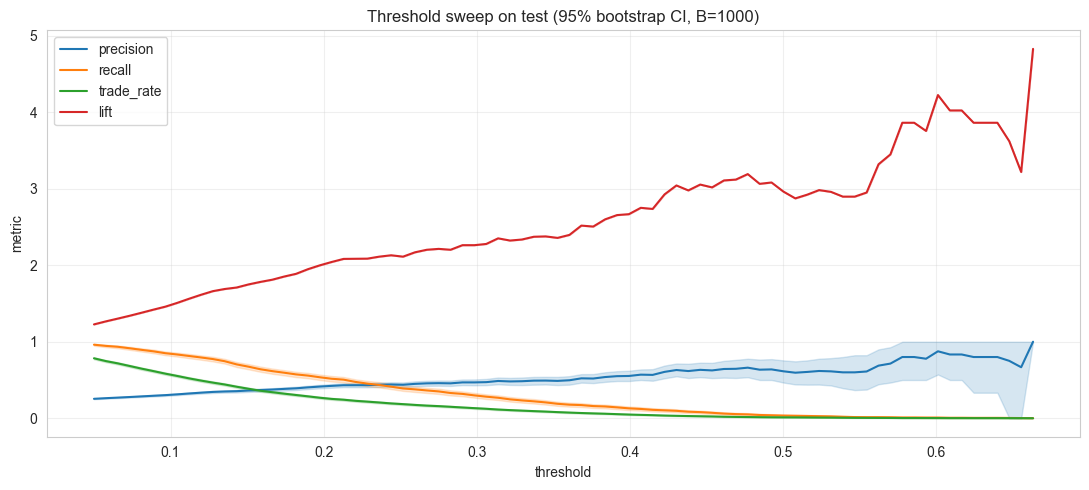

Saved: C:\Users\vitil\OneDrive\Desktop\barrier_classifier\data\model_dataset\plots\research_threshold_sweep.png


In [22]:
# Threshold sweep with bootstrap bands (precision / recall / trade rate / lift)
fig, ax = plt.subplots(figsize=(11, 5))
plot_threshold_sweep_with_bands(sweep, ax=ax, metrics=("precision", "recall", "trade_rate", "lift"))
ax.set_title(f"Threshold sweep on test (95% bootstrap CI, B={BOOTSTRAP_B})")
plt.tight_layout()
fig.savefig(PLOTS_DIR / "research_threshold_sweep.png", dpi=150)
plt.show()
print(f"Saved: {PLOTS_DIR / 'research_threshold_sweep.png'}")


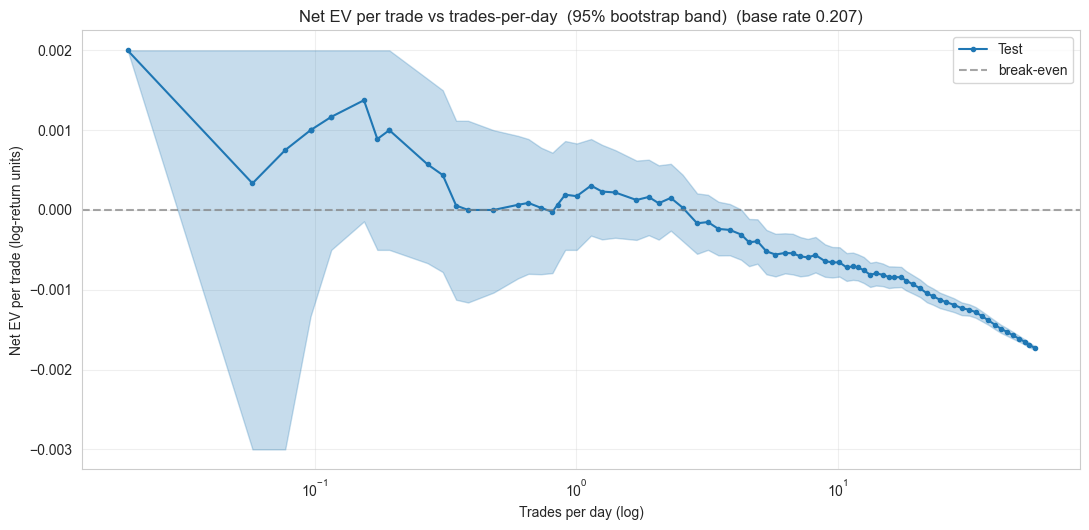

Saved: C:\Users\vitil\OneDrive\Desktop\barrier_classifier\data\model_dataset\plots\research_net_ev_curve.png

EV-maximizing threshold: 0.663  =>  EV/trade +0.00200 [+0.00200, +0.00200]  @ 0.0 trades/day,  precision 1.000,  Sharpe/trade nan


In [23]:
# THE canonical chart: Net EV per trade vs trades-per-day (log-x, with band)
fig, ax = plt.subplots(figsize=(11, 5.4))
plot_net_ev_vs_trades_per_day(
    sweep, ax=ax, color="C0", label="Test",
    base_rate=float(test_cache["y"].mean()),
)
plt.tight_layout()
fig.savefig(PLOTS_DIR / "research_net_ev_curve.png", dpi=150)
plt.show()
print(f"Saved: {PLOTS_DIR / 'research_net_ev_curve.png'}")

# Annotate the EV-maximizing threshold (within the bootstrap band of the optimum)
sweep_clean = sweep.dropna(subset=["ev_per_trade"]).reset_index(drop=True)
if len(sweep_clean) > 0:
    best = sweep_clean.iloc[sweep_clean["ev_per_trade"].idxmax()]
    print()
    print(f"EV-maximizing threshold: {best['threshold']:.3f}  "
          f"=>  EV/trade {best['ev_per_trade']:+.5f} "
          f"[{best['ev_per_trade_ci_low']:+.5f}, {best['ev_per_trade_ci_high']:+.5f}]  "
          f"@ {best['trades_per_day']:.1f} trades/day,  "
          f"precision {best['precision']:.3f},  Sharpe/trade {best['sharpe_per_trade']:.3f}")


,bin,p_lo,p_hi,n,n_hits,mean_p,hit_rate,hit_rate_ci_low,hit_rate_ci_high,kelly,kelly_ci_low,kelly_ci_high,half_kelly
0,0,0.010,0.024,373,8,0.017,0.021,0.011,0.042,-0.957,-0.978,-0.917,-0.479
1,1,0.024,0.045,373,20,0.034,0.054,0.035,0.081,-0.893,-0.930,-0.837,-0.446
2,2,0.045,0.069,374,29,0.058,0.078,0.055,0.109,-0.845,-0.891,-0.782,-0.422
3,3,0.069,0.092,372,48,0.081,0.129,0.099,0.167,-0.742,-0.803,-0.666,-0.371
4,4,0.092,0.118,373,47,0.105,0.126,0.096,0.164,-0.748,-0.808,-0.673,-0.374
5,5,0.118,0.146,374,88,0.132,0.235,0.195,0.281,-0.529,-0.610,-0.438,-0.265
6,6,0.146,0.183,373,92,0.163,0.247,0.206,0.293,-0.507,-0.589,-0.414,-0.253
7,7,0.183,0.240,372,114,0.209,0.306,0.262,0.355,-0.387,-0.476,-0.290,-0.194
8,8,0.240,0.329,373,146,0.282,0.391,0.343,0.442,-0.217,-0.314,-0.116,-0.109
9,9,0.329,0.663,374,181,0.413,0.484,0.434,0.535,-0.032,-0.133,0.069,-0.016


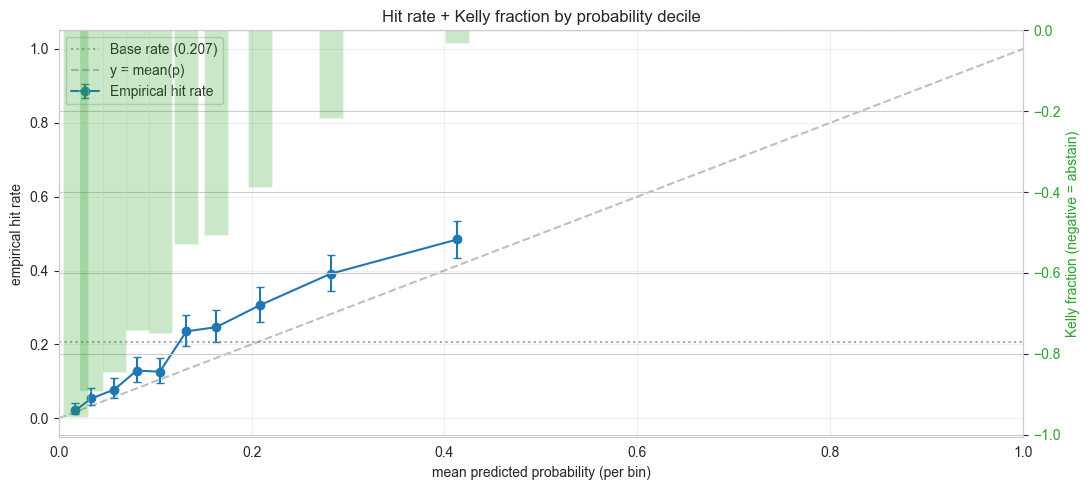

Saved: C:\Users\vitil\OneDrive\Desktop\barrier_classifier\data\model_dataset\plots\research_kelly_by_bin.png


In [24]:
# Kelly fraction per probability decile (Wilson CI on hit rate, propagated to Kelly)
kbin = kelly_by_bin(cache, split="test", n_bins=10, outcome_model=OUTCOME_MODEL)
display(kbin.style.format({
    "p_lo": "{:.3f}", "p_hi": "{:.3f}", "mean_p": "{:.3f}",
    "hit_rate": "{:.3f}", "hit_rate_ci_low": "{:.3f}", "hit_rate_ci_high": "{:.3f}",
    "kelly": "{:.3f}", "kelly_ci_low": "{:.3f}", "kelly_ci_high": "{:.3f}",
    "half_kelly": "{:.3f}",
}))

fig, ax = plt.subplots(figsize=(11, 5))
plot_kelly_by_bin(kbin, base_rate=float(test_cache["y"].mean()), ax=ax)
plt.tight_layout()
fig.savefig(PLOTS_DIR / "research_kelly_by_bin.png", dpi=150)
plt.show()
print(f"Saved: {PLOTS_DIR / 'research_kelly_by_bin.png'}")


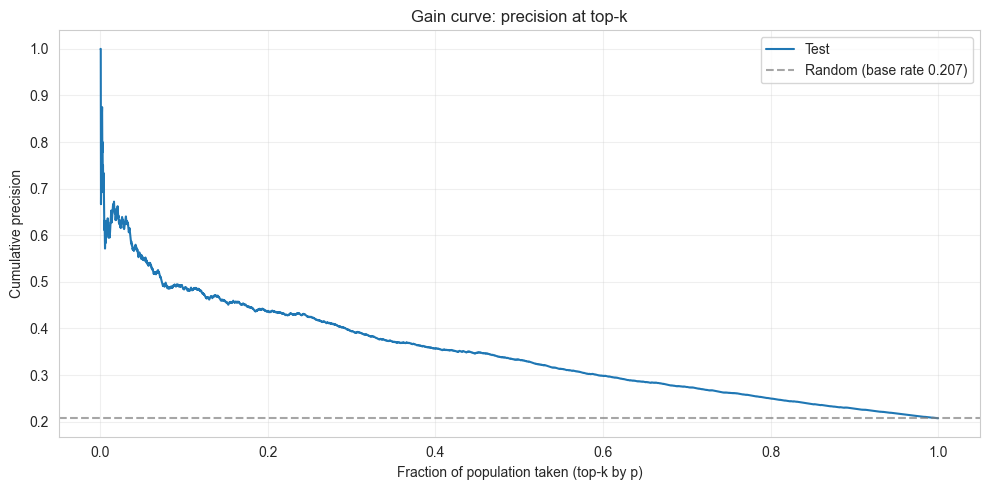

top- 1.0%: precision 0.595  lift 2.87x  recall 0.028  (k=37)
top- 2.5%: precision 0.624  lift 3.01x  recall 0.075  (k=93)
top- 5.0%: precision 0.551  lift 2.66x  recall 0.133  (k=187)
top-10.0%: precision 0.485  lift 2.34x  recall 0.234  (k=373)
top-20.0%: precision 0.437  lift 2.11x  recall 0.422  (k=746)


In [25]:
# Lift / gain curve: cumulative precision as the top-k is taken
gain = lift_curve(cache, split="test")
fig, ax = plt.subplots(figsize=(10, 5))
plot_lift_curve(gain, ax=ax, color="C0", label="Test")
plt.tight_layout()
fig.savefig(PLOTS_DIR / "research_lift_curve.png", dpi=150)
plt.show()

# Headline lift numbers at common operating points
for k_pct in [0.01, 0.025, 0.05, 0.10, 0.20]:
    k_target = int(round(k_pct * len(gain)))
    if k_target < 1:
        continue
    row = gain.iloc[k_target - 1]
    print(f"top-{k_pct:>5.1%}: precision {row['precision_at_k']:.3f}  "
          f"lift {row['lift_at_k']:.2f}x  recall {row['recall_at_k']:.3f}  (k={int(row['k'])})")


In [26]:
# Partial AUC over operating bands (low FPR, low recall)
y_test = test_cache["y"].to_numpy()
p_test = test_cache["p"].to_numpy()

partial_roc = bootstrap_partial_roc_auc(y_test, p_test, fpr_max=0.05,
    B=BOOTSTRAP_B, ci=BOOTSTRAP_CI, stratify=BOOTSTRAP_STRATIFY, seed=BOOTSTRAP_SEED)
partial_pr  = bootstrap_partial_pr_auc(y_test, p_test, recall_max=0.10,
    B=BOOTSTRAP_B, ci=BOOTSTRAP_CI, stratify=BOOTSTRAP_STRATIFY, seed=BOOTSTRAP_SEED)

print(f"Partial ROC-AUC (FPR <= 0.05) : {partial_roc.point:.3f} "
      f"[{partial_roc.ci_low:.3f}, {partial_roc.ci_high:.3f}]")
print(f"Partial PR-AUC  (recall <=0.10): {partial_pr.point:.3f} "
      f"[{partial_pr.ci_low:.3f}, {partial_pr.ci_high:.3f}]")
print()
print("These are the metrics to track on a production entry gate that operates at low FPR / low recall.")


Partial ROC-AUC (FPR <= 0.05) : 0.116 [0.095, 0.141]
Partial PR-AUC  (recall <=0.10): 0.686 [0.594, 0.800]

These are the metrics to track on a production entry gate that operates at low FPR / low recall.


In [27]:
# Save edge bundle
import json
edge_bundle = {
    "outcome_model": {
        "gain_per_hit": OUTCOME_MODEL.gain_per_hit,
        "loss_per_miss": OUTCOME_MODEL.loss_per_miss,
        "cost_per_trade": OUTCOME_MODEL.cost_per_trade,
        "use_realized_return": OUTCOME_MODEL.use_realized_return,
    },
    "ev_max": {
        "threshold": float(best["threshold"]) if len(sweep_clean) else None,
        "ev_per_trade": float(best["ev_per_trade"]) if len(sweep_clean) else None,
        "ev_ci_low": float(best["ev_per_trade_ci_low"]) if len(sweep_clean) else None,
        "ev_ci_high": float(best["ev_per_trade_ci_high"]) if len(sweep_clean) else None,
        "trades_per_day": float(best["trades_per_day"]) if len(sweep_clean) else None,
        "precision": float(best["precision"]) if len(sweep_clean) else None,
        "sharpe_per_trade": float(best["sharpe_per_trade"]) if len(sweep_clean) else None,
    },
    "kelly_first_negative_bin": int(kbin[kbin["kelly"] < 0]["bin"].min()) if (kbin["kelly"] < 0).any() else None,
    "partial_roc_auc_fpr05": partial_roc.to_dict(include_samples=False),
    "partial_pr_auc_recall10": partial_pr.to_dict(include_samples=False),
    "top_decile_lift": float(gain.iloc[int(0.10 * len(gain)) - 1]["lift_at_k"]) if len(gain) > 10 else None,
}
utils.save_json(ANALYTICS_DIR / "research_edge_summary.json", edge_bundle)
print(f"Saved edge summary: {ANALYTICS_DIR / 'research_edge_summary.json'}")
print(json.dumps(edge_bundle, indent=2, default=str))


Saved edge summary: C:\Users\vitil\OneDrive\Desktop\barrier_classifier\data\model_dataset\analytics\research_edge_summary.json
{
  "outcome_model": {
    "gain_per_hit": 0.0025,
    "loss_per_miss": 0.0025,
    "cost_per_trade": 0.0005,
    "use_realized_return": false
  },
  "ev_max": {
    "threshold": 0.6633259998590731,
    "ev_per_trade": 0.002,
    "ev_ci_low": 0.002,
    "ev_ci_high": 0.002,
    "trades_per_day": 0.0193029490616622,
    "precision": 1.0,
    "sharpe_per_trade": NaN
  },
  "kelly_first_negative_bin": 0,
  "partial_roc_auc_fpr05": {
    "point": 0.11619450517464426,
    "median": 0.1161722919361794,
    "ci_low": 0.09468801202700518,
    "ci_high": 0.1414492059872251,
    "ci": 0.95,
    "B": 1000
  },
  "partial_pr_auc_recall10": {
    "point": 0.6855233153399074,
    "median": 0.6971027320699302,
    "ci_low": 0.5943649403023276,
    "ci_high": 0.8003294231197873,
    "ci": 0.95,
    "B": 1000
  },
  "top_decile_lift": 2.342154275150956
}


---
End of Phase 0+1+2+2b+3 deliverables.

Subsequent sections land as the corresponding analytics phases are built:

- **Phase 4** `cohorts.py` -> SHAP cohort decomposition (TP/FP/TN/FN), discriminative-SHAP
- **Phase 5** `uncertainty.py` -> virtual-ensemble MI / total / data entropy decomposition, (p, knowledge_unc) gating
- **Phase 6** `audits.py` -> label-shuffle, future-feature audit, time-block permutation, turnover, latency-budget, deflated Sharpe
